<a href="https://colab.research.google.com/github/NYCBTECH/AdilNYUProjPhase1/blob/main/Adil_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import shap
import warnings
warnings.filterwarnings('ignore')

Dataset Shape: (58645, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  in

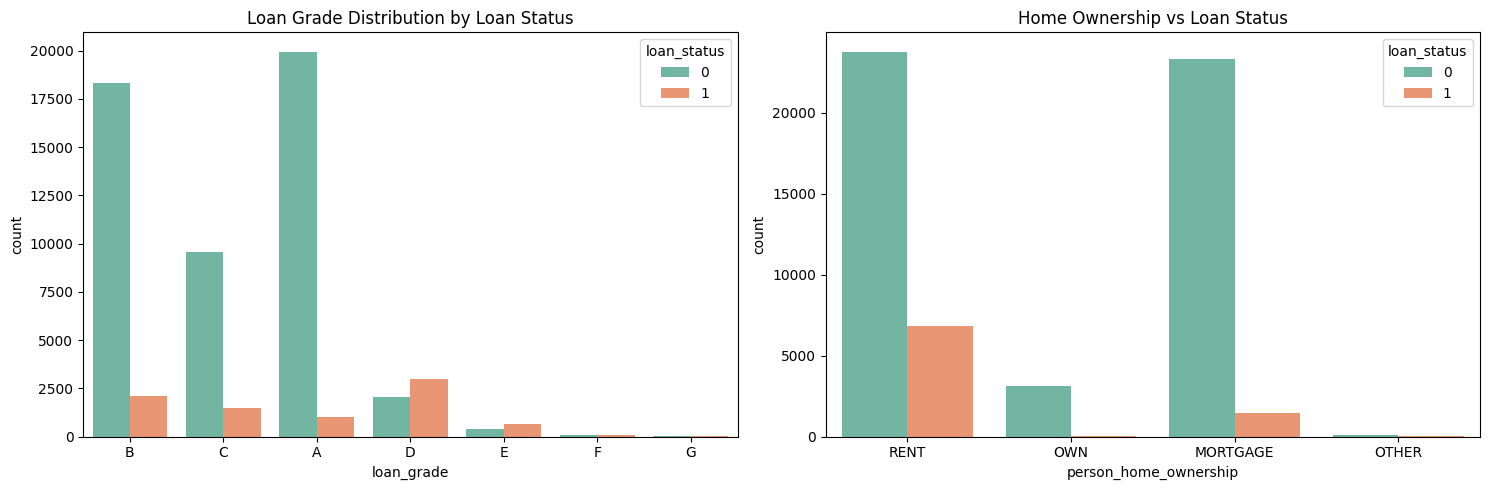

Dataset Shape: (58645, 21)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   58645 non-null  int64  
 1   person_income                58645 non-null  int64  
 2   person_home_ownership        58645 non-null  int64  
 3   person_emp_length            58645 non-null  float64
 4   loan_amnt                    58645 non-null  int64  
 5   loan_int_rate                58645 non-null  float64
 6   loan_percent_income          58645 non-null  float64
 7   cb_person_default_on_file    58645 non-null  int64  
 8   cb_person_cred_hist_length   58645 non-null  int64  
 9   loan_status                  58645 non-null  int64  
 10  loan_intent_EDUCATION        58645 non-null  bool   
 11  loan_intent_HOMEIMPROVEMENT  58645 non-null  bool   
 12  loan_intent_MEDICAL          586

In [15]:

# Load dataset
loans = pd.read_csv('https://raw.githubusercontent.com/NYCBTECH/project2/refs/heads/main/train.csv')

# Basic dataset statistics
print("Dataset Shape:", loans.shape)
print("\nDataset Info:")
print(loans.info())
print("\nMissing Values:\n", loans.isnull().sum())

# Plot Categorical Variables for Understanding
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(ax=axes[0], data=loans, x='loan_grade', hue='loan_status', palette='Set2')
axes[0].set_title("Loan Grade Distribution by Loan Status")

sns.countplot(ax=axes[1], data=loans, x='person_home_ownership', hue='loan_status', palette='Set2')
axes[1].set_title("Home Ownership vs Loan Status")

plt.tight_layout()
plt.show()

# Convert binary categorical variables to numeric
loans['cb_person_default_on_file'] = loans['cb_person_default_on_file'].replace({'Y': 1, 'N': 0})
loans['person_home_ownership'] = loans['person_home_ownership'].replace({'OWN': 1, 'RENT': 0, 'MORTGAGE': 1, 'OTHER': 0})

# Convert remaining categorical variables into dummy variables
cat_cols = loans.select_dtypes(include=['object']).columns
loans = pd.get_dummies(loans, columns=cat_cols, drop_first=True)

# Ensure all dummy variables are numeric
dummy_cols = loans.columns.difference(cat_cols)
loans[dummy_cols] = loans[dummy_cols].apply(pd.to_numeric)

# Remove non-informative columns like 'id'
df = loans.drop(columns=['id'])

# Basic dataset statistics
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())


       person_age  person_income  person_home_ownership  person_emp_length  loan_amnt  loan_int_rate  loan_percent_income  cb_person_default_on_file  cb_person_cred_hist_length  loan_status  loan_intent_EDUCATION  loan_intent_HOMEIMPROVEMENT  loan_intent_MEDICAL  loan_intent_PERSONAL  loan_intent_VENTURE  loan_grade_B  loan_grade_C  loan_grade_D  loan_grade_E  loan_grade_F  loan_grade_G
10522          22          60000                      1                4.0      10000          10.37                 0.17                          0                           4            0                   True                        False                False                 False                False          True         False         False         False         False         False
48340          25          30000                      1                3.0      10000           6.99                 0.33                          0                           3            0                  False        

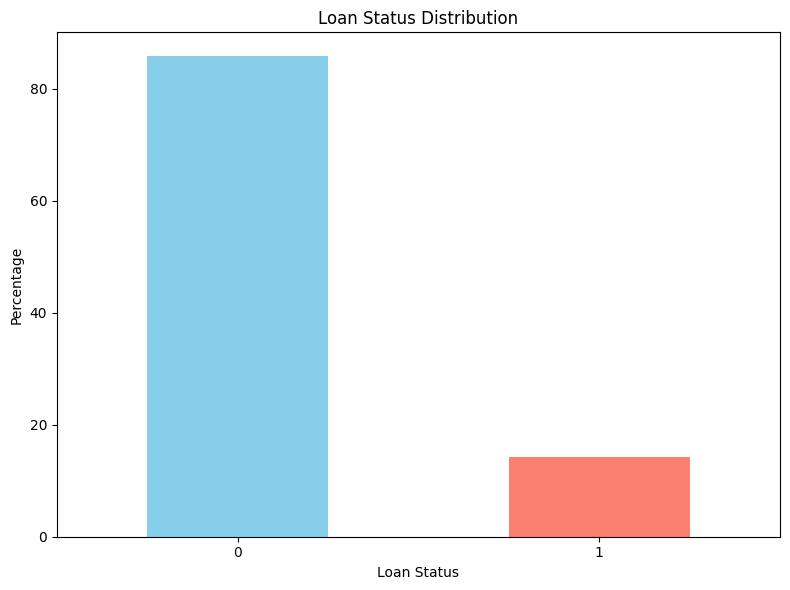

In [7]:
# 2. Identify target variable (assuming it's called 'target')
target = 'loan_status'  # This is the target variable
X = df.drop(columns=[target])
y = df[target]

# Print 20 random rows with data labels
print(df.sample(n=20).to_string())

# Calculate and print loan_status distribution percentage
loan_status_dist = df['loan_status'].value_counts(normalize=True) * 100
print("\nLoan Status Distribution Percentage:\n", loan_status_dist)

# Create a bar chart of loan_status distribution
plt.figure(figsize=(8, 6))
loan_status_dist.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Percentage')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.tight_layout()
plt.show()

In [6]:
# 3. Univariate statistics
print("Univariate Statistics:")
print(X.describe())   # Shows count, mean, std, min, max, quartiles

Univariate Statistics:
         person_age  person_income  person_home_ownership  person_emp_length  \
count  58645.000000   5.864500e+04           58645.000000       58645.000000   
mean      27.550857   6.404617e+04               0.476801           4.701015   
std        6.033216   3.793111e+04               0.499466           3.959784   
min       20.000000   4.200000e+03               0.000000           0.000000   
25%       23.000000   4.200000e+04               0.000000           2.000000   
50%       26.000000   5.800000e+04               0.000000           4.000000   
75%       30.000000   7.560000e+04               1.000000           7.000000   
max      123.000000   1.900000e+06               1.000000         123.000000   

          loan_amnt  loan_int_rate  loan_percent_income  \
count  58645.000000   58645.000000         58645.000000   
mean    9217.556518      10.677874             0.159238   
std     5563.807384       3.034697             0.091692   
min      500.000000 

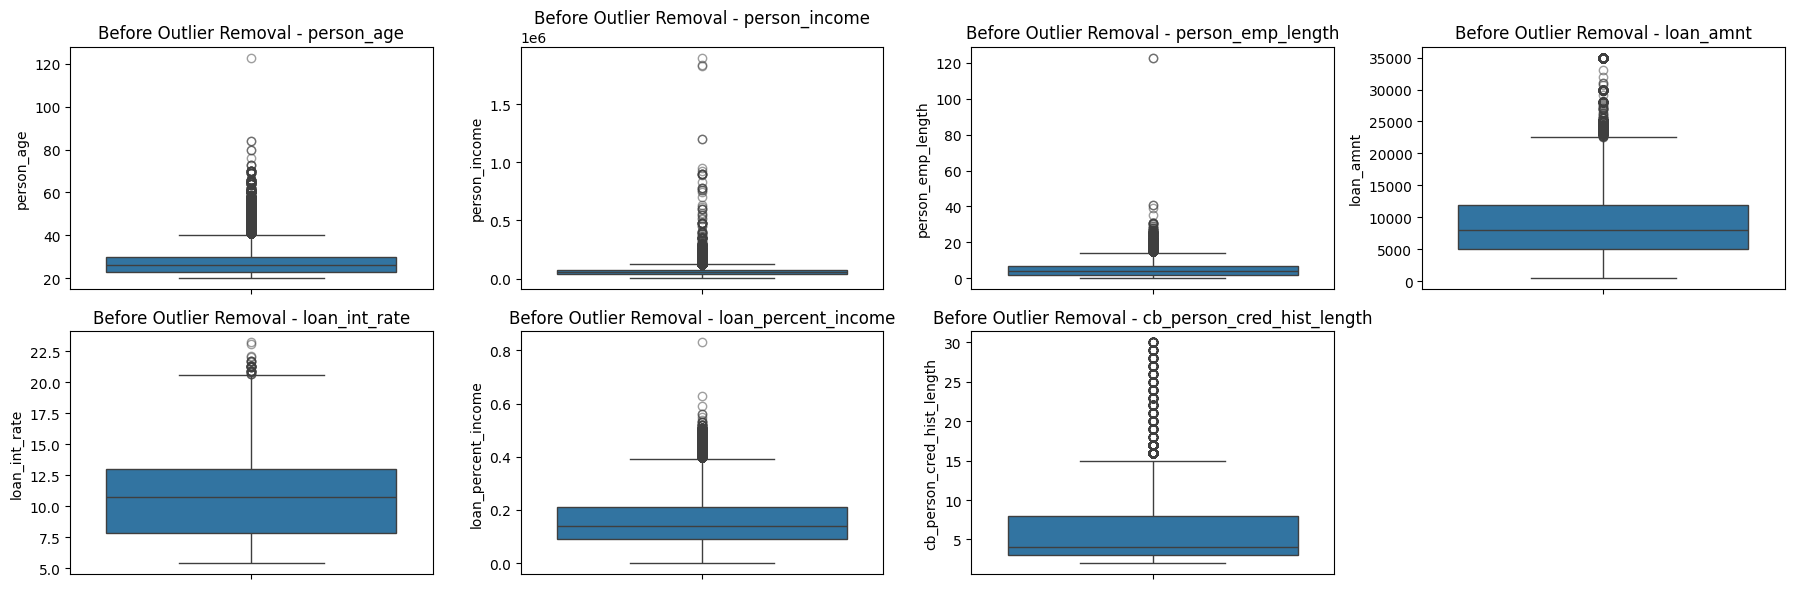

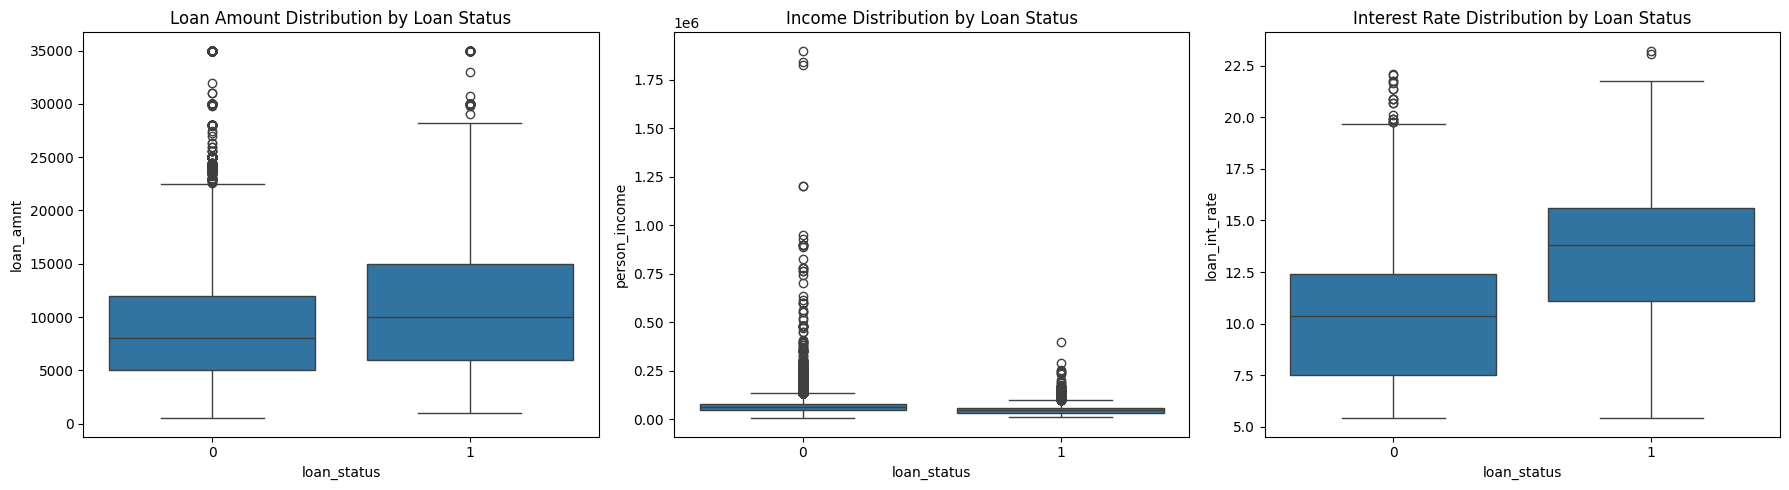

In [17]:

# 4 Outlier Processing
# Function to remove outliers (only for continuous numeric variables)
def remove_outliers(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    continuous_cols = [col for col in numeric_cols if X[col].nunique() > 10]  # Exclude dummy variables (usually have 2 unique values)

    X_numeric = X[continuous_cols].copy()

    # Compute IQR and filter outliers only for continuous variables
    Q1 = X_numeric.quantile(0.25)
    Q3 = X_numeric.quantile(0.75)
    IQR = Q3 - Q1
    X_numeric = X_numeric[~((X_numeric < (Q1 - 1.5 * IQR)) | (X_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]

    # Merge back unchanged categorical/dummy variables
    X_clean = pd.concat([X_numeric, X.drop(columns=continuous_cols)], axis=1)

    return X_clean

# Store original data for comparison
X_original = X.copy()

# Identify continuous numeric variables (excluding dummy variables)
continuous_cols = [col for col in X_original.select_dtypes(include=[np.number]).columns if X_original[col].nunique() > 10]

# Plot individual box plots for continuous numeric variables (excluding dummy variables)
plt.figure(figsize=(18, 6))
for i, column in enumerate(continuous_cols):
    plt.subplot(2, (len(continuous_cols) + 1) // 2, i + 1)
    sns.boxplot(y=X_original[column], flierprops=dict(marker='o', color='red', alpha=0.5))
    plt.title(f"Before Outlier Removal - {column}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], data=loans, x='loan_status', y='loan_amnt')
axes[0].set_title("Loan Amount Distribution by Loan Status")

sns.boxplot(ax=axes[1], data=loans, x='loan_status', y='person_income')
axes[1].set_title("Income Distribution by Loan Status")

sns.boxplot(ax=axes[2], data=loans, x='loan_status', y='loan_int_rate')
axes[2].set_title("Interest Rate Distribution by Loan Status")

plt.tight_layout()
plt.show()

# Remove outliers only from continuous numeric variables
X_clean = remove_outliers(X)
y_clean = y[X_clean.index]

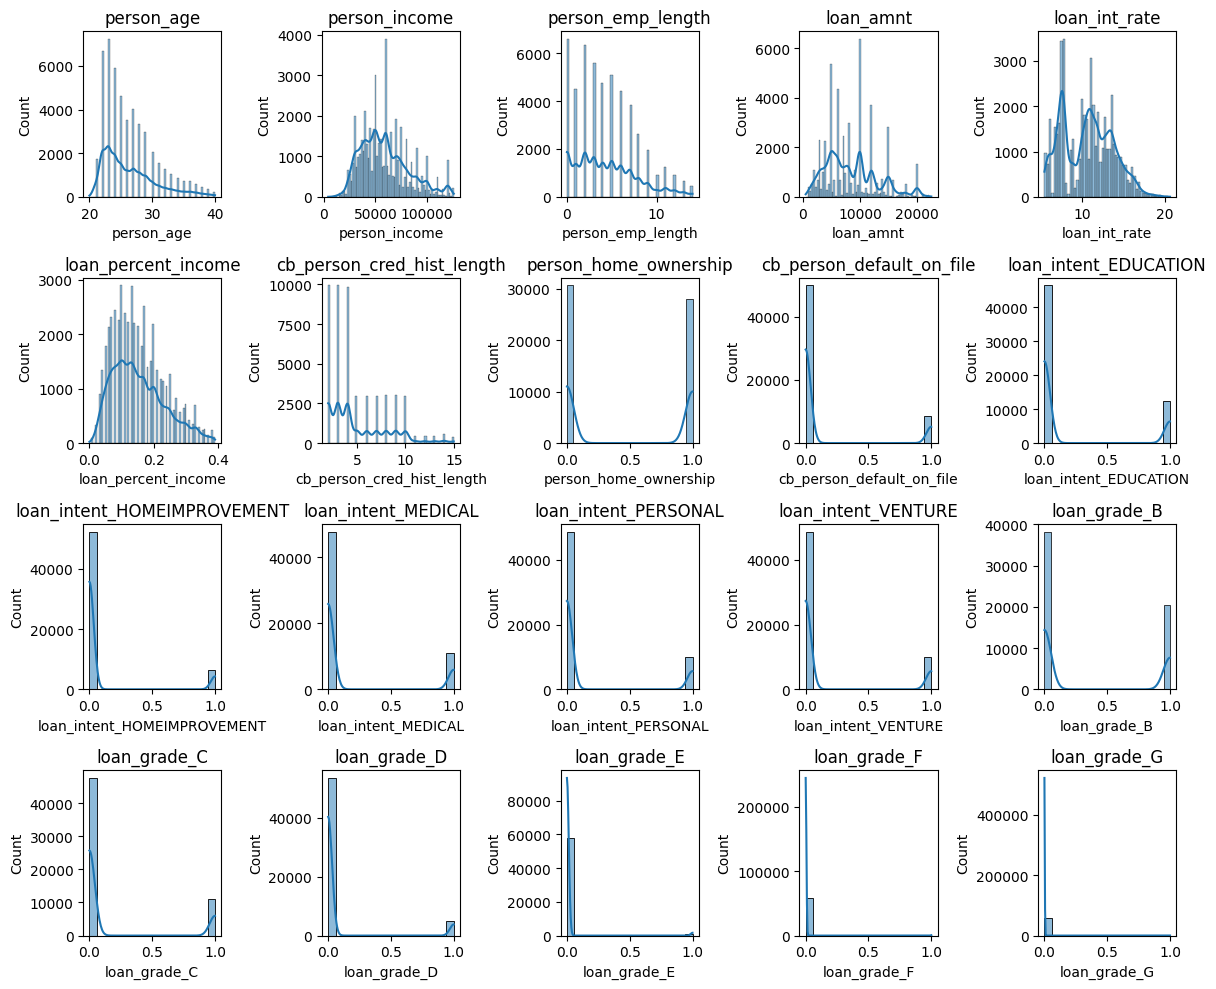

In [11]:

# 5 Advanced Data Visualizations
# Define number of rows and columns
num_rows = 4
num_cols = (len(X_clean.columns) + num_rows - 1) // num_rows  # Adjust column count dynamically

plt.figure(figsize=(12, 10))  # Increase figure size for better visualization
for i, column in enumerate(X_clean.columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(X_clean[column], kde=True)
    plt.title(column)

plt.tight_layout()
plt.show()

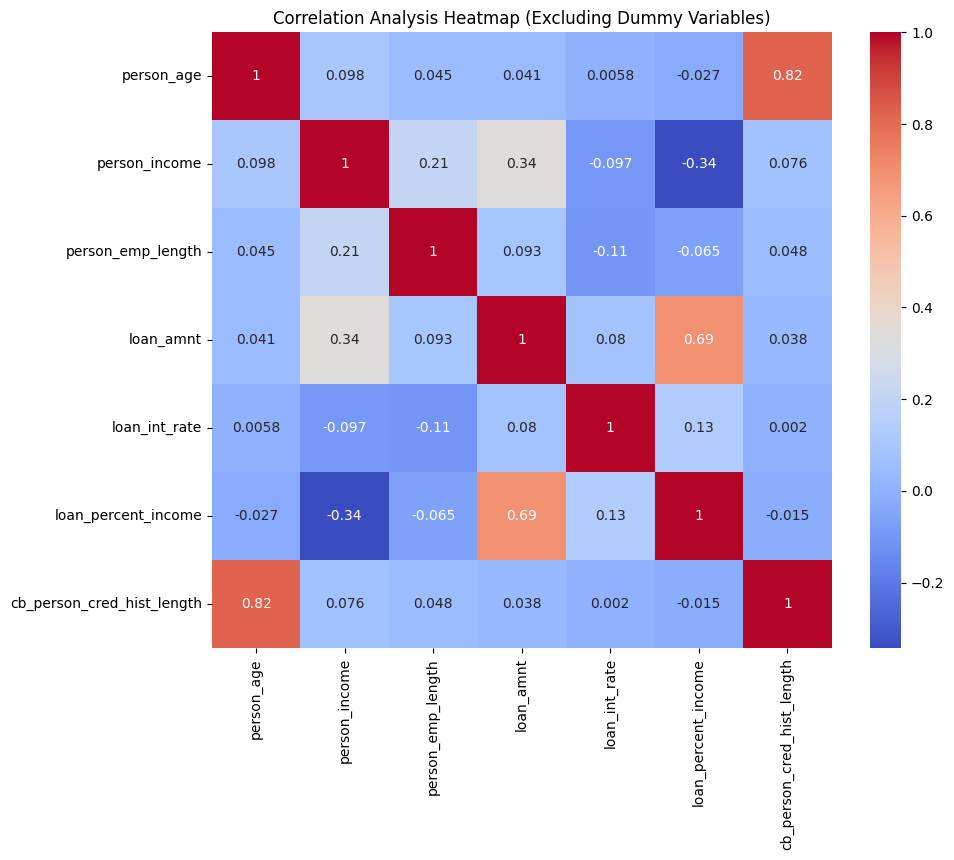

Removed variables due to high correlation: []


In [18]:
# 6 Correlation

# Identify numeric continuous variables (excluding dummy variables) - preparing for correlation analysis
numeric_cols = X_clean.select_dtypes(include=[np.number]).columns
continuous_cols = [col for col in numeric_cols if X_clean[col].nunique() > 10]  # Exclude dummy variables (binary features)

# Compute correlation matrix only for continuous numeric variables
correlation_matrix = X_clean[continuous_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Analysis Heatmap (Excluding Dummy Variables)")
plt.show()

# Remove highly correlated variables (>0.85)
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > 0.85)]
X_final = X_clean.drop(columns=to_drop)
print(f"Removed variables due to high correlation: {to_drop}")

In [21]:
# 7. Split data (70% train, 30% test)

X_train, X_test, y_train, y_test = train_test_split(
    X_final.drop(columns=['loan_int_rate']),  # Exclude loan_int_rate
    y_clean,
    test_size=0.3,
    random_state=42
)

In [22]:
# 8. XGBoost model
params = {
    'max_depth': 3,
    'n_estimators': 20,
    #'objective': 'binary:logistic',  # Assuming binary classification
    'learning_rate': 0.05,           # Low regularization
    'reg_alpha': 0.1,             # L1 regularization
    'reg_lambda': 0.1,            # L2 regularization
    'eval_metric': 'auc',
    #'monotone_constraints': tuple([1] * X_final.shape[1])  # Enforce monotonicity
}

model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=20, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [23]:
# 9. Calculate AUC
train_pred = model.predict_proba(X_train)[:, 1]
test_pred = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_pred)
test_auc = roc_auc_score(y_test, test_pred)
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

Train AUC: 0.8911
Test AUC: 0.8893


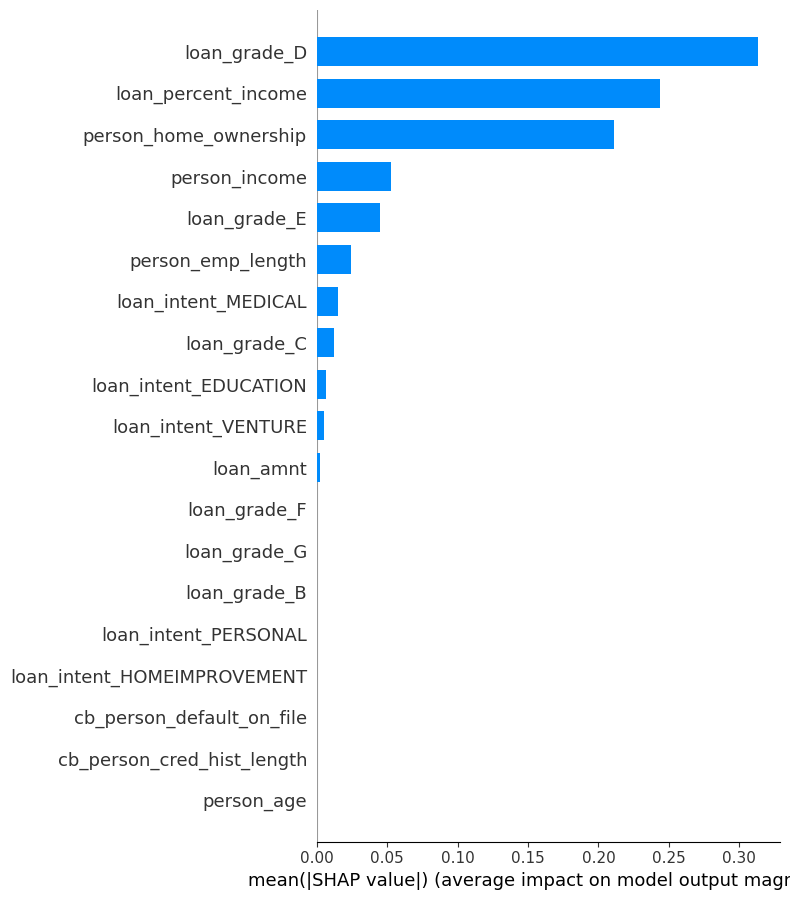

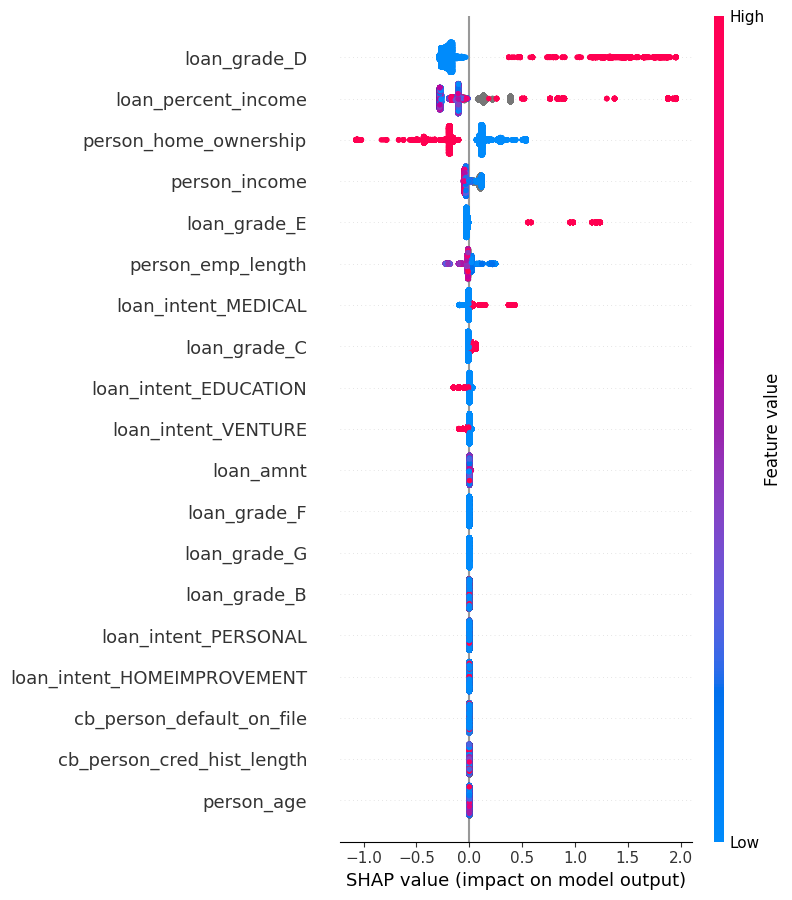

In [24]:
# 10. SHAP plots
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

# Detailed SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)
plt.show()

# Save the model
model.save_model('xgboost_model.json')

In [25]:
# 11. Split data based on person_home_ownership
loans_own = loans[loans['person_home_ownership'] == 1]
loans_rent = loans[loans['person_home_ownership'] == 0]

# Print data elements and loan_status ratio for 'own' group
print("\nLoans - Own Group:")
print("Data Elements:", loans_own.shape[0])
loan_status_own_ratio = loans_own['loan_status'].value_counts(normalize=True)
print("Loan Status Ratio:\n", loan_status_own_ratio)

# Print data elements and loan_status ratio for 'rent' group
print("\nLoans - Rent Group:")
print("Data Elements:", loans_rent.shape[0])
loan_status_rent_ratio = loans_rent['loan_status'].value_counts(normalize=True)
print("Loan Status Ratio:\n", loan_status_rent_ratio)


Loans - Own Group:
Data Elements: 27962
Loan Status Ratio:
 loan_status
0    0.945426
1    0.054574
Name: proportion, dtype: float64

Loans - Rent Group:
Data Elements: 30683
Loan Status Ratio:
 loan_status
0    0.777597
1    0.222403
Name: proportion, dtype: float64


In [29]:
# 12. Function to create train/test sets and train XGBoost model

def train_and_evaluate(data, target_column):
    X = data.drop(columns=[target_column, 'id', 'loan_int_rate'])  # Exclude 'id', 'loan_int_rate'
    y = data[target_column]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # XGBoost parameters
    params = {
        'max_depth': 3,
        'n_estimators': 20,
        'learning_rate': 0.05,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'eval_metric': 'auc'
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    # Calculate AUCs
    train_pred = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]
    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    return model, train_auc, test_auc, X_train, X_test, y_train, y_test

# Split data based on person_home_ownership
loans_own = loans[loans['person_home_ownership'] == 1]
loans_rent = loans[loans['person_home_ownership'] == 0]

# Train and evaluate for 'own' group
model_own, train_auc_own, _, X_train_own, X_test_own, y_train_own, y_test_own = train_and_evaluate(loans_own, 'loan_status')
print(f"Own Train AUC: {train_auc_own:.4f}")

# Train and evaluate for 'rent' group
model_rent, train_auc_rent, _, X_train_rent, X_test_rent, y_train_rent, y_test_rent = train_and_evaluate(loans_rent, 'loan_status')
print(f"Rent Train AUC: {train_auc_rent:.4f}")

# Calculate AUC for Own Test segment using Own model
test_pred_own = model_own.predict_proba(X_test_own)[:, 1]
test_auc_own = roc_auc_score(y_test_own, test_pred_own)
print(f"Own Test AUC: {test_auc_own:.4f}")

# Calculate AUC for Rent Test segment using Rent model
test_pred_rent = model_rent.predict_proba(X_test_rent)[:, 1]
test_auc_rent = roc_auc_score(y_test_rent, test_pred_rent)
print(f"Rent Test AUC: {test_auc_rent:.4f}")

# Calculate combined Test AUC
all_test_preds = np.concatenate([test_pred_own, test_pred_rent])
all_test_labels = np.concatenate([y_test_own, y_test_rent])
combined_test_auc = roc_auc_score(all_test_labels, all_test_preds)
print(f"Combined Test AUC: {combined_test_auc:.4f}")

# Calculate combined Train AUC
all_train_preds = np.concatenate([model_own.predict_proba(X_train_own)[:, 1], model_rent.predict_proba(X_train_rent)[:, 1]])
all_train_labels = np.concatenate([y_train_own, y_train_rent])
combined_train_auc = roc_auc_score(all_train_labels, all_train_preds)
print(f"Combined Train AUC: {combined_train_auc:.4f}")

Own Train AUC: 0.8254
Rent Train AUC: 0.9039
Own Test AUC: 0.8168
Rent Test AUC: 0.8970
Combined Test AUC: 0.8928
Combined Train AUC: 0.8968
